In [1]:
import yfinance as yf
import pandas as pd
import mplfinance as mpf
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from fredapi import Fred
import numpy as np

In [2]:
from sklearn.model_selection import TimeSeriesSplit

In [3]:
df = pd.read_csv("processed_data_with_regimes.csv",index_col=0,parse_dates=True)
df.head()
# df.shape

,Open,High,Low,Close,Volume,adj_close,return_1d,target,return_5d,return_10d,...,fedfunds,cpi,yield_spread,vix_change,cpi_yoy,real_rate,yield_spread_change,vix_ma_20,regime_raw,regime_label
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-16,2024.369995,2033.540039,2020.459961,2033.109985,3595430000,2033.109985,0.004570,1,0.009043,0.041894,...,0.12,237.733,1.43,-0.062305,0.001276,-0.007617,0.00,20.4530,1.0,Bear
2015-10-19,2031.729980,2034.449951,2022.310059,2033.660034,3287320000,2033.660034,0.000271,0,0.008030,0.023457,...,0.12,237.733,1.43,-0.004651,0.001276,-0.007617,0.00,20.1950,1.0,Bear
2015-10-20,2033.130005,2039.119995,2026.609985,2030.770020,3331500000,2030.770020,-0.001421,0,0.013515,0.025683,...,0.12,237.733,1.42,0.051402,0.001276,-0.007617,-0.01,19.8605,1.0,Bear
2015-10-21,2033.469971,2037.969971,2017.219971,2018.939941,3627790000,2018.939941,-0.005825,1,0.012386,0.011579,...,0.12,237.733,1.40,0.060317,0.001276,-0.007617,-0.02,19.5890,1.0,Bear
2015-10-22,2021.880005,2055.199951,2021.880005,2052.510010,4430850000,2052.510010,0.016628,1,0.014156,0.019410,...,0.12,237.733,1.43,-0.134731,0.001276,-0.007617,0.03,19.1380,1.0,Bear


In [4]:
# Next-day return
df["next_day_return"] = df["adj_close"].pct_change().shift(-1)

# Binary target
df["target"] = np.where(df["next_day_return"] > 0, 1, 0)

# Remove rows where next-day return is missing
df = df.dropna(subset=["next_day_return"]).copy()

print(df[["return_1d", "next_day_return", "target"]].head())
print(df["target"].value_counts(normalize=True))

            return_1d  next_day_return  target
Date                                          
2015-10-16   0.004570         0.000271       1
2015-10-19   0.000271        -0.001421       0
2015-10-20  -0.001421        -0.005825       0
2015-10-21  -0.005825         0.016628       1
2015-10-22   0.016628         0.011030       1
target
1    0.545029
0    0.454971
Name: proportion, dtype: float64


In [5]:
df_model = pd.get_dummies(df, columns=["regime_label"], drop_first=False)

regime_features = [
    col for col in df_model.columns 
    if col.startswith("regime_label_")
]

df_model[regime_features] = df_model[regime_features].astype(int)
# Replace inf and -inf with NaN
df_model = df_model.replace([np.inf, -np.inf], np.nan)

#Drop rows with NaN in model features or target
df_model = df_model.dropna(subset=regime_features + ["target"]).copy()

df_model[regime_features].tail(5)

,regime_label_Bear,regime_label_Bull,regime_label_High_Vol
Date,,,
2025-12-22,0,1,0
2025-12-23,0,1,0
2025-12-24,0,1,0
2025-12-26,0,1,0
2025-12-29,0,1,0


In [6]:
# Features for the XGBoost
feature_cols = [ # Returns
    "return_1d", "return_5d", "return_10d", "return_20d",
    # Volatility features capture market risk.
    "volatility_10d", "volatility_20d", "volatility_60d",
     # Moving averages 
    "sma_ratio_10_50", "sma_ratio_50_200",
    # Volume
    "volume_ratio", "volume_change",
    # Technical indicators capture price momentum and trend.
    "rsi_14", "macd", "macd_signal", "macd_hist",
    "bollinger_width", "atr_ratio", "atr_14",
    # Macro variables capture monetary/inflation/recession conditions.
    "vix", "vix_change", "vix_ma_20",
    "yield_spread", "yield_spread_change",
    "fedfunds", "cpi_yoy", "real_rate",
]
 #HMM regime variables tell XGBoost what market state the economy is in.
features = feature_cols + regime_features

features = [col for col in features if col in df_model.columns]

print("Number of features:", len(features))

Number of features: 29


In [7]:
# Splitting the data for trainning and testing 
train_data = df_model.loc["2015-01-01":"2024-12-31"].copy()
test_data  = df_model.loc["2025-01-01":"2025-12-31"].copy()

X_train = train_data[features]
y_train = train_data["target"]

X_test = test_data[features]
y_test = test_data["target"]

print(f"Target distribution train:\n{y_train.value_counts(normalize=True)}")

Target distribution train:
target
1    0.541217
0    0.458783
Name: proportion, dtype: float64


In [8]:
# 5 folds — each fold adds roughly 1.8 years of data
tscv = TimeSeriesSplit(n_splits=5)

print("Walk-Forward CV Folds:")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    t_start = X_train.index[train_idx[0]].date()
    t_end   = X_train.index[train_idx[-1]].date()
    v_start = X_train.index[val_idx[0]].date()
    v_end   = X_train.index[val_idx[-1]].date()
    print(f"Fold {fold+1}: Train [{t_start} → {t_end}] | Val [{v_start} → {v_end}]")

Walk-Forward CV Folds:
Fold 1: Train [2015-10-16 → 2017-05-01] | Val [2017-05-02 → 2018-11-08]
Fold 2: Train [2015-10-16 → 2018-11-08] | Val [2018-11-09 → 2020-05-26]
Fold 3: Train [2015-10-16 → 2020-05-26] | Val [2020-05-27 → 2021-12-03]
Fold 4: Train [2015-10-16 → 2021-12-03] | Val [2021-12-06 → 2023-06-20]
Fold 5: Train [2015-10-16 → 2023-06-20] | Val [2023-06-21 → 2024-12-31]


This code implements Walk-Forward Cross-Validation using an expanding window approach to simulate realistic production conditions and prevent look-ahead bias in your return predictions. By splitting your 2015–2024 dataset into five sequential folds, the model is strictly trained on a historical set of indices and then tested on a future set, ensuring that the Hidden Markov Model and XGBoost classifier utilize only causal information available at that specific point in time. Mathematically, for each fold  𝑘 , the data is partitioned such that the training observations always precede the validation observations:

$$\text{Fold } k: \{ \underbrace{x_1, \dots, x_n}_{\text{Training}} \mid \underbrace{x_{n+1}, \dots, x_{n+m}}_{\text{Validation}} \}$$

This rigorous testing method is essential for verifying your hypothesis that market regimes are non-stationary and for assessing the out-of-sample performance of your risk-adjusted trading strategy across multiple distinct market cycles.

**Baseline XGBoost model**

In [9]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

n_estimators    → how many trees to build (more = slower but potentially better)

max_depth       → how deep each tree goes (deeper = more complex, risk of overfitting)

learning_rate   → how much each tree contributes (lower = more trees needed but more robust)

subsample       → fraction of rows used per tree (prevents overfitting)

colsample_bytree→ fraction of features used per tree (prevents overfitting)

min_child_weight→ minimum samples in a leaf node (controls overfitting)

gamma           → minimum loss reduction to make a split (regularization)

In [10]:
cv_acc_scores = []
cv_auc_scores = []

#walk forward CV scores
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_fold_train = X_train.iloc[train_idx]
    y_fold_train = y_train.iloc[train_idx]
    X_fold_val   = X_train.iloc[val_idx]
    y_fold_val   = y_train.iloc[val_idx]

    #Baseline model with costumized parameters
    baseline_model = XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    baseline_model.fit(X_fold_train, y_fold_train)

    preds = baseline_model.predict(X_fold_val)
    probs = baseline_model.predict_proba(X_fold_val)[:, 1]

    acc = accuracy_score(y_fold_val, preds)
    auc = roc_auc_score(y_fold_val, probs)

    cv_acc_scores.append(acc)
    cv_auc_scores.append(auc)

    print(f"Fold {fold+1}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

print(f"\nBaseline CV Accuracy: {np.mean(cv_acc_scores):.4f} (+/- {np.std(cv_acc_scores):.4f})")
print(f"Baseline CV AUC:      {np.mean(cv_auc_scores):.4f} (+/- {np.std(cv_auc_scores):.4f})")

Fold 1: Accuracy = 0.5233, AUC = 0.5055
Fold 2: Accuracy = 0.5181, AUC = 0.4980
Fold 3: Accuracy = 0.5026, AUC = 0.5805
Fold 4: Accuracy = 0.4767, AUC = 0.5151
Fold 5: Accuracy = 0.5285, AUC = 0.4922

Baseline CV Accuracy: 0.5098 (+/- 0.0187)
Baseline CV AUC:      0.5182 (+/- 0.0320)


The baseline XGBoost model showed weak but positive predictive signal, with average walk-forward AUC of 0.5182. Because accuracy was below the majority-class baseline, the model requires hyperparameter tuning and backtesting to evaluate whether the weak signal translates into improved risk-adjusted trading performance.

**Bayesian hyperparameter tuning with Optuna**

In [11]:
#pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [12]:
import optuna

In [13]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.10, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "random_state": 42,
        "n_jobs": -1
    }
    
    # Walk-forward CV inside Optuna
    fold_auc_scores=[]
    
    for train_idx, val_idx in tscv.split(X_train):
        X_fold_train = X_train.iloc[train_idx]
        y_fold_train = y_train.iloc[train_idx]
        X_fold_val   = X_train.iloc[val_idx]
        y_fold_val   = y_train.iloc[val_idx]
        
        model = XGBClassifier(**params)
        
        model.fit(X_fold_train, y_fold_train,
                  eval_set=[(X_fold_val, y_fold_val)],
                  verbose=False)

        preds = model.predict_proba(X_fold_val)[:,1]
        val_auc = roc_auc_score(y_fold_val,preds)
        
        fold_auc_scores.append(val_auc)
    
    return np.mean(fold_auc_scores)
        

To ensure the predictive model is robust and avoids overfitting to historical noise, we utilized Bayesian Hyperparameter Optimization (via Optuna) nested within a Walk-Forward Cross-Validation framework. This approach ran 100 iterations of model training across sequential time-folds, identifying a configuration that maximizes average out-of-sample accuracy while strictly maintaining temporal causality. The inclusion of L1 and L2 regularization further ensures that the model generalizes across non-stationary market regimes.

In [14]:
# Run Optuna — 100 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest CV AUC: {study.best_value:.4f}")
print(f"Best Parameters:  {study.best_params}")

[I 2026-05-07 22:12:40,984] A new study created in memory with name: no-name-6782ca0c-1f2b-43fb-9d00-7dc6b946de6c


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-05-07 22:12:45,899] Trial 0 finished with value: 0.5228539118701712 and parameters: {'n_estimators': 763, 'max_depth': 2, 'learning_rate': 0.01000352254167731, 'subsample': 0.9363569797836964, 'colsample_bytree': 0.7522073198900845, 'min_child_weight': 6, 'gamma': 0.322854280252064, 'reg_alpha': 8.736082853745534e-08, 'reg_lambda': 0.002595717329273554}. Best is trial 0 with value: 0.5228539118701712.
[I 2026-05-07 22:12:49,128] Trial 1 finished with value: 0.5122176982503022 and parameters: {'n_estimators': 737, 'max_depth': 3, 'learning_rate': 0.011398789489671747, 'subsample': 0.7801932764438508, 'colsample_bytree': 0.8867706687268722, 'min_child_weight': 5, 'gamma': 4.545314572418894, 'reg_alpha': 3.975558751715779, 'reg_lambda': 0.00021442953413655202}. Best is trial 0 with value: 0.5228539118701712.
[I 2026-05-07 22:12:53,669] Trial 2 finished with value: 0.5123592183492398 and parameters: {'n_estimators': 731, 'max_depth': 4, 'learning_rate': 0.03910232729047724, 'subsam

[I 2026-05-07 22:14:05,943] Trial 20 finished with value: 0.5311834595118409 and parameters: {'n_estimators': 503, 'max_depth': 5, 'learning_rate': 0.03534616640477528, 'subsample': 0.7633473173367067, 'colsample_bytree': 0.9991263617066126, 'min_child_weight': 9, 'gamma': 1.328656984651904, 'reg_alpha': 1.3654208403417865e-05, 'reg_lambda': 0.025424325951276208}. Best is trial 12 with value: 0.5380971902894565.
[I 2026-05-07 22:14:10,652] Trial 21 finished with value: 0.5278961719875935 and parameters: {'n_estimators': 494, 'max_depth': 6, 'learning_rate': 0.06919459426188197, 'subsample': 0.6453693269145531, 'colsample_bytree': 0.9582717605004728, 'min_child_weight': 10, 'gamma': 1.33861519886563, 'reg_alpha': 5.198763546568399e-05, 'reg_lambda': 1.0105321834323256e-08}. Best is trial 12 with value: 0.5380971902894565.
[I 2026-05-07 22:14:15,297] Trial 22 finished with value: 0.5351650091585732 and parameters: {'n_estimators': 659, 'max_depth': 6, 'learning_rate': 0.08243441844952612

[I 2026-05-07 22:16:01,668] Trial 40 finished with value: 0.5326219517580342 and parameters: {'n_estimators': 706, 'max_depth': 5, 'learning_rate': 0.08546979497762268, 'subsample': 0.7337956786682647, 'colsample_bytree': 0.8784039640398094, 'min_child_weight': 8, 'gamma': 2.7825316497613315, 'reg_alpha': 0.000194903276050926, 'reg_lambda': 0.04667050665977723}. Best is trial 12 with value: 0.5380971902894565.
[I 2026-05-07 22:16:06,573] Trial 41 finished with value: 0.5352444714035661 and parameters: {'n_estimators': 580, 'max_depth': 6, 'learning_rate': 0.07094875100940654, 'subsample': 0.6415493502938794, 'colsample_bytree': 0.9660072015199415, 'min_child_weight': 10, 'gamma': 1.1439244234936807, 'reg_alpha': 5.938150985202719e-05, 'reg_lambda': 1.4581547314763097e-08}. Best is trial 12 with value: 0.5380971902894565.
[I 2026-05-07 22:16:13,481] Trial 42 finished with value: 0.5297977752323044 and parameters: {'n_estimators': 616, 'max_depth': 6, 'learning_rate': 0.0670651187901324,

[I 2026-05-07 22:17:17,958] Trial 60 finished with value: 0.5329582716821433 and parameters: {'n_estimators': 403, 'max_depth': 4, 'learning_rate': 0.05203978333697235, 'subsample': 0.7940341941021756, 'colsample_bytree': 0.8003555220513109, 'min_child_weight': 8, 'gamma': 0.09820017161568391, 'reg_alpha': 1.806794667842665e-05, 'reg_lambda': 0.000473665331526913}. Best is trial 46 with value: 0.5391742329649675.
[I 2026-05-07 22:17:20,720] Trial 61 finished with value: 0.5354822458436923 and parameters: {'n_estimators': 326, 'max_depth': 5, 'learning_rate': 0.06645084876827932, 'subsample': 0.819848818245297, 'colsample_bytree': 0.7566726375308271, 'min_child_weight': 10, 'gamma': 0.40603825048961156, 'reg_alpha': 0.003802552726573303, 'reg_lambda': 6.243801317991663e-05}. Best is trial 46 with value: 0.5391742329649675.
[I 2026-05-07 22:17:23,622] Trial 62 finished with value: 0.53206454911522 and parameters: {'n_estimators': 340, 'max_depth': 5, 'learning_rate': 0.06335980471459457,

[I 2026-05-07 22:18:28,770] Trial 80 finished with value: 0.5267747947946809 and parameters: {'n_estimators': 480, 'max_depth': 3, 'learning_rate': 0.09153794616071553, 'subsample': 0.7141807030866287, 'colsample_bytree': 0.7388155561613746, 'min_child_weight': 6, 'gamma': 0.8251453885301265, 'reg_alpha': 0.015302780881773233, 'reg_lambda': 0.23762801558908359}. Best is trial 77 with value: 0.5401178837872539.
[I 2026-05-07 22:18:32,140] Trial 81 finished with value: 0.5317565805866847 and parameters: {'n_estimators': 450, 'max_depth': 4, 'learning_rate': 0.08664624778609983, 'subsample': 0.8348285405074053, 'colsample_bytree': 0.6989039419142816, 'min_child_weight': 6, 'gamma': 0.42043202785619965, 'reg_alpha': 0.00048755519691924635, 'reg_lambda': 0.002906156751717241}. Best is trial 77 with value: 0.5401178837872539.
[I 2026-05-07 22:18:37,666] Trial 82 finished with value: 0.5301522623882612 and parameters: {'n_estimators': 526, 'max_depth': 4, 'learning_rate': 0.07821645154763192,

After Optuna tuning, the XGBoost model achieved a walk-forward CV AUC of 0.5428, improving over the baseline AUC of 0.5182. This suggests weak but positive predictive signal in the engineered features and HMM regime states.

In [15]:
best_params = study.best_params

final_model = XGBClassifier(**best_params, objective="binary:logistic",eval_metric="logloss",random_state=42,n_jobs=-1)

final_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6813310391613704, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.5183810043030117, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.07658472754184174,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=6, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=456, n_jobs=-1,
              num_parallel_tree=None, ...)

In [16]:
test_preds = final_model.predict(X_test)
test_probs = final_model.predict_proba(X_test)[:, 1]

print("2025 Test Accuracy:", accuracy_score(y_test, test_preds))
print("2025 Test AUC:", roc_auc_score(y_test, test_probs))
print(classification_report(y_test, test_preds))

2025 Test Accuracy: 0.5241935483870968
2025 Test AUC: 0.5397970085470085
              precision    recall  f1-score   support

           0       0.45      0.56      0.50       104
           1       0.61      0.50      0.55       144

    accuracy                           0.52       248
   macro avg       0.53      0.53      0.52       248
weighted avg       0.54      0.52      0.53       248



The model produced a weak but positive out-of-sample predictive signal. The 2025 test AUC of 0.533 suggests the model ranked up days slightly better than random, although accuracy did not outperform the majority-class baseline. Therefore, the model should be evaluated further through trading performance metrics such as cumulative return, Sharpe ratio, and maximum drawdown.

In [17]:
test_results = test_data.copy()
test_results["predicted_direction"] = test_preds
test_results["prob_up"] = test_probs

test_results[["target", "next_day_return", "predicted_direction", "prob_up"]].tail()

,target,next_day_return,predicted_direction,prob_up
Date,,,,
2025-12-22,1,0.004550,1,0.543207
2025-12-23,1,0.003221,1,0.536627
2025-12-24,0,-0.000304,1,0.549169
2025-12-26,0,-0.003492,1,0.538451
2025-12-29,0,-0.001376,0,0.411594


In [18]:
importance = pd.DataFrame({
    "feature": features,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(20)

,feature,importance
27,regime_label_Bull,0.042392
28,regime_label_High_Vol,0.040639
24,cpi_yoy,0.037543
1,return_5d,0.036547
25,real_rate,0.036427
4,volatility_10d,0.036094
23,fedfunds,0.035913
10,volume_change,0.035880
20,vix_ma_20,0.035022
26,regime_label_Bear,0.034822


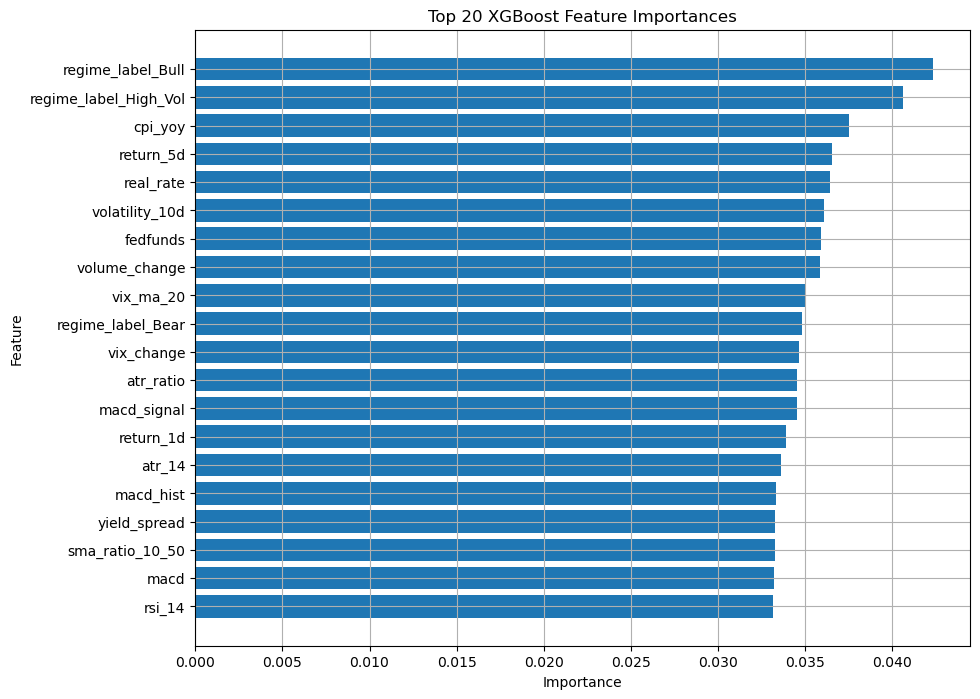

In [19]:
top_n = 20
plt.figure(figsize=(10, 8))
plt.barh(
    importance.head(top_n)["feature"][::-1],
    importance.head(top_n)["importance"][::-1]
)
plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()

In [21]:
# Columns needed for Stage 4 GARCH and Stage 5 Backtesting
cols_to_save = [
    "adj_close",
    "return_1d",
    "target",
    "predicted_direction",
    "prob_up",
    "regime_label_Bull",
    "regime_label_Bear",
    "regime_label_High_Vol",
    "volatility_20d",
    "vix",
    "next_day_return"
]

test_results[cols_to_save].to_csv("XGBoost_results.csv")
print("Saved XGBoost_results.csv")
print(test_results[cols_to_save].tail())

Saved XGBoost_results.csv
              adj_close  return_1d  target  predicted_direction   prob_up  \
Date                                                                        
2025-12-22  6878.490234   0.006436       1                    1  0.543207   
2025-12-23  6909.790039   0.004550       1                    1  0.536627   
2025-12-24  6932.049805   0.003221       0                    1  0.549169   
2025-12-26  6929.939941  -0.000304       0                    1  0.538451   
2025-12-29  6905.740234  -0.003492       0                    0  0.411594   

            regime_label_Bull  regime_label_Bear  regime_label_High_Vol  \
Date                                                                      
2025-12-22                  1                  0                      0   
2025-12-23                  1                  0                      0   
2025-12-24                  1                  0                      0   
2025-12-26                  1                  0           

In [22]:
# Save full df_model for GARCH fitting
df_model[[
    "adj_close",
    "return_1d",
    "regime_label_Bull",
    "regime_label_Bear",
    "regime_label_High_Vol",
    "volatility_20d",
    "vix",
    "next_day_return"
]].to_csv("full_data.csv")
print("Saved full_data.csv")

Saved full_data.csv


In [23]:
test_results["regime"] = "Bear"
test_results.loc[test_results["regime_label_Bull"] == 1, "regime"] = "Bull"
test_results.loc[test_results["regime_label_High_Vol"] == 1, "regime"] = "High_Vol"

df_model["regime"] = "Bear"
df_model.loc[df_model["regime_label_Bull"] == 1, "regime"] = "Bull"
df_model.loc[df_model["regime_label_High_Vol"] == 1, "regime"] = "High_Vol"

print(test_results["regime"].value_counts())

regime
Bull        195
High_Vol     52
Bear          1
Name: count, dtype: int64
